## Summary
1. Year-over-Year (YoY) Growth
2. Credit Composition (Private vs. Government)
3. Money Aggregate Comparison ($M2$ vs $M3$)
4.Seasonal Decomposition
5.Correlation Heatmap
6. Rolling Volatility (The "Stress" Test)
7. The Money Multiplier Analysis (Efficiency)
8. The Backing Ratio (Currency Stability)
9. The "Lazy Money" Analysis (Excess Liquidity)-Liquidity Buffer Ratio
10. The 'Crowding Out' Index (Government vs. Private Credit)
11. Sources of Money Supply Growth (NFA vs. NDA)
12. SOE vs. Private Sector Credit Tension


## Data Acquisition & Wrangling

Implement dual-row header parsing for date construction.

Use label-based filtering via dictionary mapping for target indicators.

Clean string-formatted currency values into floats (comma removal).

Align disparate rows into a single Time-Series DataFrame.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

def extract_monetary_data(file_path):
    # Use 'low_memory=False' because monetary data often has mixed types
    df = pd.read_csv(file_path, low_memory=False)

    # 1. Extract Dates (Years and Months)
    years_row = df.columns.tolist()
    current_year = None
    years = []
    for col in years_row:
        if col.isdigit(): current_year = col
        years.append(current_year)
    
    # Months are in the second row (index 1)
    months = df.iloc[1].tolist()
    
    # Create the date index (aligning with data columns)
    date_strings = [f"{y}-{m}" for y, m in zip(years[2:], months[2:]) if pd.notna(y) and pd.notna(m)]
    dates = pd.to_datetime(date_strings, format='%Y-%b', errors='coerce')

    # 2. Target Dictionary
    target_indicators = {
        "Net Foreign assets": "NFA",
        "Net Domestic Assets": "NDA",
        "Reserve Money": "Reserve_Money",
        "Currency in circulation": "Currency_Circ",
        "Banks Reserves at CBK": "Total_Reserves",
        "Public Non Financial Corp": "SOE_Credit",
        "Private sector credit ": "Private_Credit", 
        "Central Government (Net)": "Gov_Credit",
        "Money and Quasi-money (M2)": "M2",
        "M2 plus Residents' Foreign Curr. Deposits (M3)": "M3",
        "Required reserves": "Req_Reserves",
        "Excess reserves": "Excess_Reserves"
    }

    cleaned_series = []
    labels_col = df.columns[1] 

    # 3. Process each indicator
    for label, short_name in target_indicators.items():
        mask = df[labels_col].astype(str).str.strip().str.contains(label.strip(), case=False, na=False, regex=False)
        
        if mask.any():
            row_data = df[mask].iloc[-1, 2:].values 
            
            clean_vals = []
            for x in row_data:
                try:
                    s = str(x).replace(',', '').strip()
                    clean_vals.append(float(s) if s != '' else np.nan)
                except ValueError:
                    clean_vals.append(np.nan)
            
            cleaned_series.append(pd.Series(clean_vals[:len(dates)], name=short_name))
        else:
            print(f"⚠️ Warning: Could not find label '{label}' in CSV.")

    if not cleaned_series:
        print("❌ No data was extracted. Check your CSV labels.")
        return pd.DataFrame()

    monetary_df = pd.concat(cleaned_series, axis=1)
    monetary_df.index = dates
    return monetary_df

# --- DYNAMIC EXECUTION ---

# Path Logic for: notebooks/python/notebook_name.ipynb
# Path.cwd() gets '.../cbk-macroeconomic-analysis/notebooks/python'
# .parent.parent moves up two steps to '.../cbk-macroeconomic-analysis/'
project_root = Path.cwd().parent.parent 

# Target path: data/cleaned/monetary.csv
csv_path = project_root / 'data' / 'cleaned' / 'monetary.csv'

if csv_path.exists():
    print(f"✅ Found file at: {csv_path}")
    df_monetary = extract_monetary_data(csv_path)
    
    if not df_monetary.empty:
        # Perform calculations
        if 'Excess_Reserves' in df_monetary.columns and 'Req_Reserves' in df_monetary.columns:
            df_monetary['Liquidity_Buffer_Ratio'] = (df_monetary['Excess_Reserves'] / 
                                                    (df_monetary['Req_Reserves'] + df_monetary['Excess_Reserves'])) * 100
        
        if 'M3' in df_monetary.columns and 'Reserve_Money' in df_monetary.columns:
            df_monetary['Money_Multiplier'] = df_monetary['M3'] / df_monetary['Reserve_Money']

        # Save to the same folder as the input data
        output_path = csv_path.parent / 'monetary_analyzed.csv'
        df_monetary.to_csv(output_path)
        print(f"📊 Analysis saved to: {output_path}")
        print(df_monetary[['M2', 'M3', 'Gov_Credit']].tail())
else:
    print(f"❌ File not found at {csv_path}")
    print(f"Current Working Directory is: {Path.cwd()}")

✅ Found file at: d:\Asaph_Ray\DATA SCIENCE\DATA ANALYSIS\CBK MACROECONOMIC ANALYSIS\cbk-macroeconomic-analysis\data\cleaned\monetary.csv
📊 Analysis saved to: d:\Asaph_Ray\DATA SCIENCE\DATA ANALYSIS\CBK MACROECONOMIC ANALYSIS\cbk-macroeconomic-analysis\data\cleaned\monetary_analyzed.csv
                   M2        M3  Gov_Credit
2025-07-01  11.843577  6.727829   20.776003
2025-08-01   9.775533  7.214904   21.540094
NaT         11.135488  7.576694   32.337368
2025-10-01  11.288173  8.489005   22.424007
2025-11-01  10.677925  8.376810   12.473543


## 1. Year-over-Year (YoY) Growth
The YoY growth rate removes "seasonal noise" (like typical December spending spikes) by comparing a month to the same month in the previous year.
$$\text{YoY Growth} = \left( \frac{\text{Value}_{t}}{\text{Value}_{t-12}} - 1 \right) \times 100$$

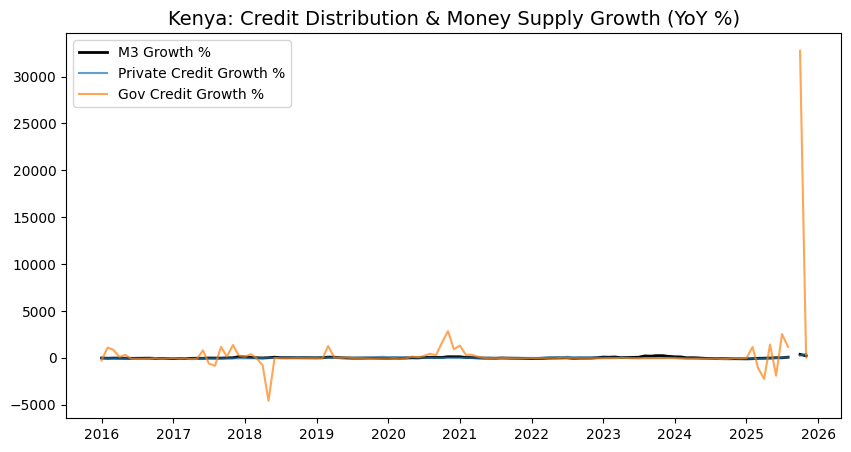

In [2]:
import matplotlib.pyplot as plt

# 1. Run the extraction (ensure you use a new variable name 'df_monetary')
df_monetary = extract_monetary_data(csv_path)

# 2. Calculating YoY Growth safely
# We drop all-NaN rows first to ensure the 12-month window is accurate
df_yoy = df_monetary.pct_change(periods=12) * 100

# 3. Visualization: The Big Three (M3, Private Credit, Govt Credit)
plt.figure(figsize=(10, 5))
plt.plot(df_yoy.index, df_yoy['M3'], label='M3 Growth %', color='black', linewidth=2)
plt.plot(df_yoy.index, df_yoy['Private_Credit'], label='Private Credit Growth %', alpha=0.7)
plt.plot(df_yoy.index, df_yoy['Gov_Credit'], label='Gov Credit Growth %', alpha=0.7)
plt.title('Kenya: Credit Distribution & Money Supply Growth (YoY %)', fontsize=14)
plt.legend()

## 2. Credit Composition (Private vs. Government)
This analysis identifies who is receiving the most credit in this economy. A high share of government credit relative to private credit can signal "Crowding Out," where government borrowing makes it harder or more expensive for businesses to get loans.

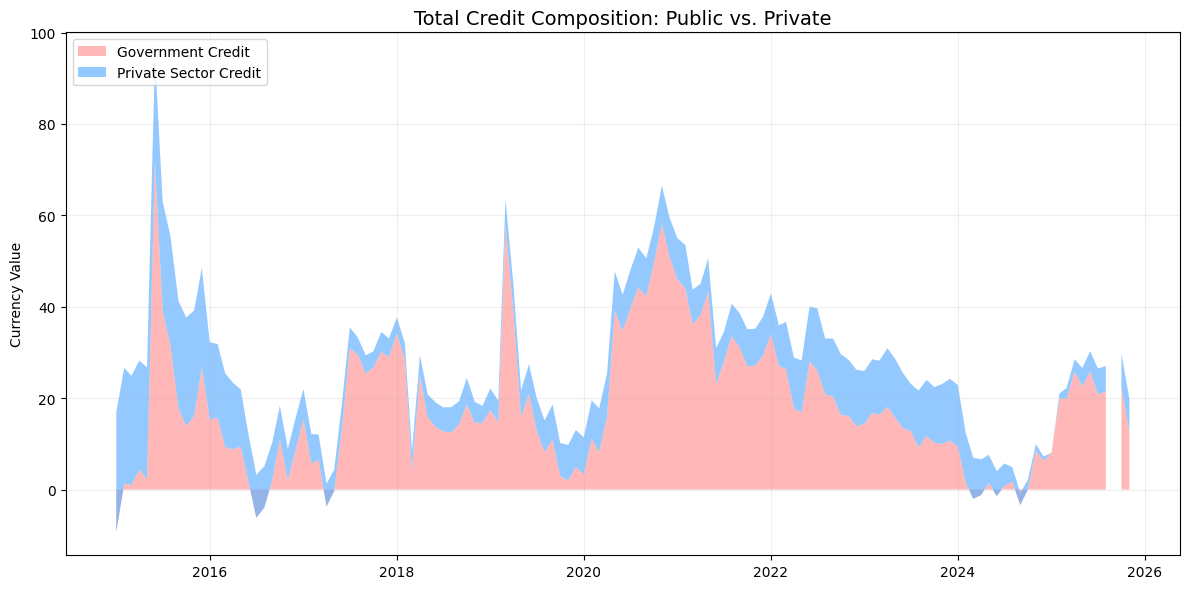

In [3]:
# 1. Calculating the Private Sector's share of total credit
total_credit = df_monetary['Private_Credit'] + df_monetary['Gov_Credit']
df_monetary['Private_Credit_Share'] = (df_monetary['Private_Credit'] / total_credit) * 100

# 2. Visualizing with a Stacked Area Chart
plt.figure(figsize=(12, 6))
plt.stackplot(df_monetary.index, 
              df_monetary['Gov_Credit'], 
              df_monetary['Private_Credit'], 
              labels=['Government Credit', 'Private Sector Credit'],
              alpha=0.7, colors=['#ff9999','#66b3ff'])

plt.title('Total Credit Composition: Public vs. Private', fontsize=14)
plt.ylabel('Currency Value')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 3. Money Aggregate Comparison ($M2$ vs $M3$)
Comparing $M2$ and $M3$ shows the "liquidity depth." If the gap between $M3$ and $M2$ is widening, it usually means residents are holding more foreign currency deposits or long-term savings.

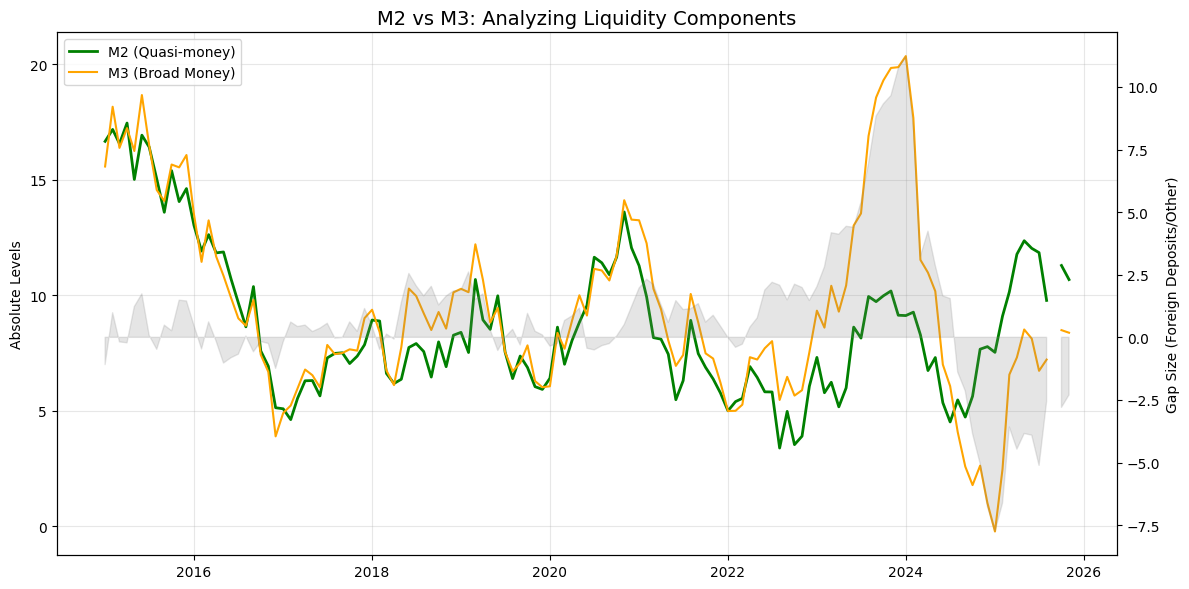

In [7]:
# 1. Let's calculate the spread/gap
df_monetary['M3_M2_Gap'] = df_monetary['M3'] - df_monetary['M2']

# 2. Visualize Levels and the Gap
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df_monetary.index, df_monetary['M2'], label='M2 (Quasi-money)', color='green', linewidth=2)
ax1.plot(df_monetary.index, df_monetary['M3'], label='M3 (Broad Money)', color='orange')
ax1.set_ylabel('Absolute Levels')
ax1.legend(loc='upper left')

# Creating a second y-axis for the gap
ax2 = ax1.twinx()
ax2.fill_between(df_monetary.index, df_monetary['M3_M2_Gap'], color='gray', alpha=0.2, label='M3-M2 Gap')
ax2.set_ylabel('Gap Size (Foreign Deposits/Other)')

plt.title('M2 vs M3: Analyzing Liquidity Components', fontsize=14)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.Seasonal Decomposition
This is the "X-Ray" of the data. It breaks  M2 or Private_Credit into three distinct parts:

Trend: The long-term "true" direction (ignoring the monthly ups and downs).

Seasonal: The repeating yearly cycle (e.g., do people always withdraw cash in December?).

Residual: The "shocks" or unexpected events (like a sudden policy change).

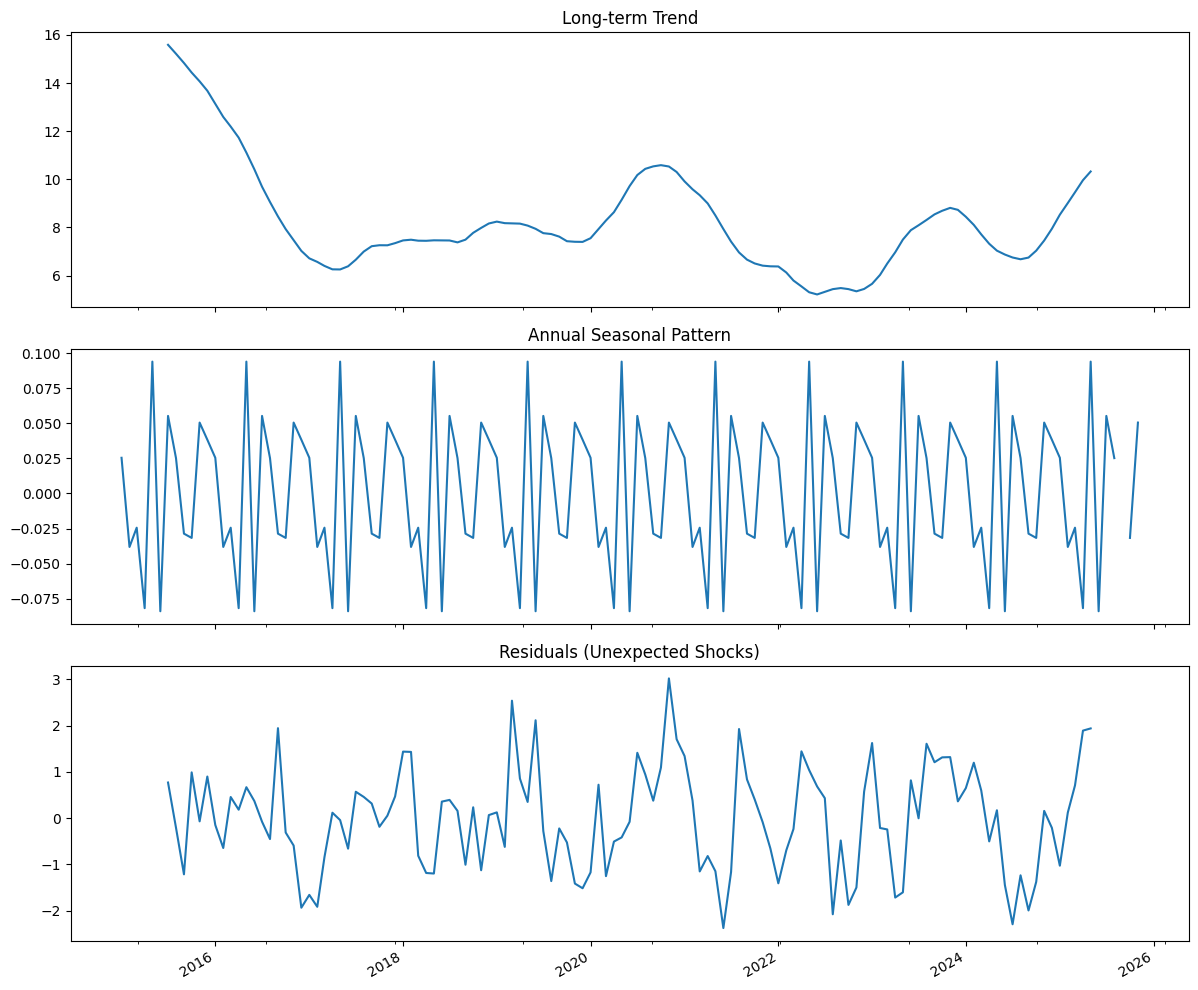

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# We'll use M2 as the primary example
# Ensure 'monetary' has a frequency set (usually monthly 'MS')
result = seasonal_decompose(df_monetary['M2'].dropna(), model='additive', period=12)

# Plotting
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
result.trend.plot(ax=ax1, title='Long-term Trend')
result.seasonal.plot(ax=ax2, title='Annual Seasonal Pattern')
result.resid.plot(ax=ax3, title='Residuals (Unexpected Shocks)')
plt.tight_layout()
plt.show()

## 5.Correlation Heatmap
This tells how "synchronized" these variables are.

A 1.0 (dark red) means they move perfectly together.

A 0 means they have nothing to do with each other.

A negative number means when one goes up, the other goes down (uncommon in monetary aggregates but possible in credit).

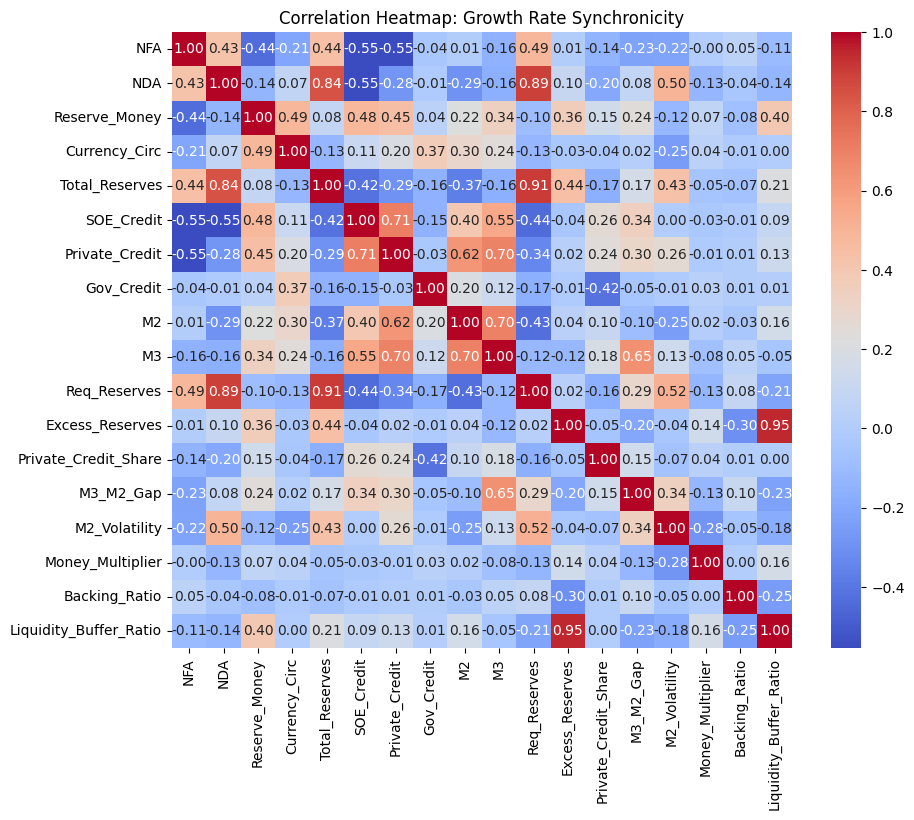

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 8))
# We calculate the correlation of the growth rates, not the absolute levels, 
# because absolute levels almost always trend up together (which can be misleading).

sns.heatmap(df_monetary.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Growth Rate Synchronicity')
plt.show()

## 6. Rolling Volatility (The "Stress" Test)
A calculation of a Rolling Standard Deviation. This tells how "jumpy" the credit growth is. Huge spikes in this chart usually marks a period of economic crisis or massive policy shifts.

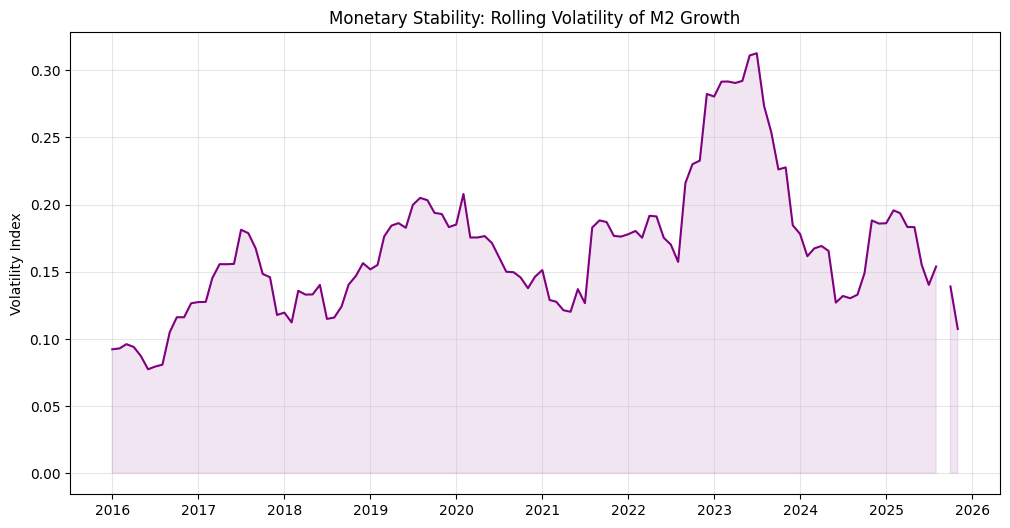

In [ ]:
# Calculate the volatility (Standard Deviation) of M2 growth over a 12-month window
df_monetary['M2_Volatility'] = df_monetary['M2'].pct_change().rolling(window=12).std()

plt.figure(figsize=(12, 6))
plt.plot(df_monetary.index, df_monetary['M2_Volatility'], color='purple', label='M2 Volatility (12m Window)')
plt.fill_between(df_monetary.index, df_monetary['M2_Volatility'], color='purple', alpha=0.1)
plt.title('Monetary Stability: Rolling Volatility of M2 Growth')
plt.ylabel('Volatility Index')
plt.grid(True, alpha=0.3)
plt.show()

## 7. The Money Multiplier Analysis (Efficiency)
A critical metric for a Central Bank. It tells us how effectively the CBK's "Reserve Money" is being turned into "Broad Money" by the commercial banks. If this ratio drops, it means banks are holding onto cash rather than lending it out.
$$\text{Money Multiplier} = \frac{M3}{\text{Reserve Money}}$$

## 8. The Backing Ratio (Currency Stability)
This measures how much of Kenya's money supply is backed by actual foreign reserves (dollars, gold, etc.) versus domestic debt.High Ratio: Stronger support for the KES exchange rate.Low Ratio: Suggests the money supply is largely driven by domestic borrowing.
$$\text{Backing Ratio} = \frac{\text{NFA}}{\text{M3}}$$

I'm trying to look at the specific Monetary Survey structure of Kenya. Just moved from just looking at "how much money exists" to "how that money is backed" and 'how effectively the banking system is creating it.'

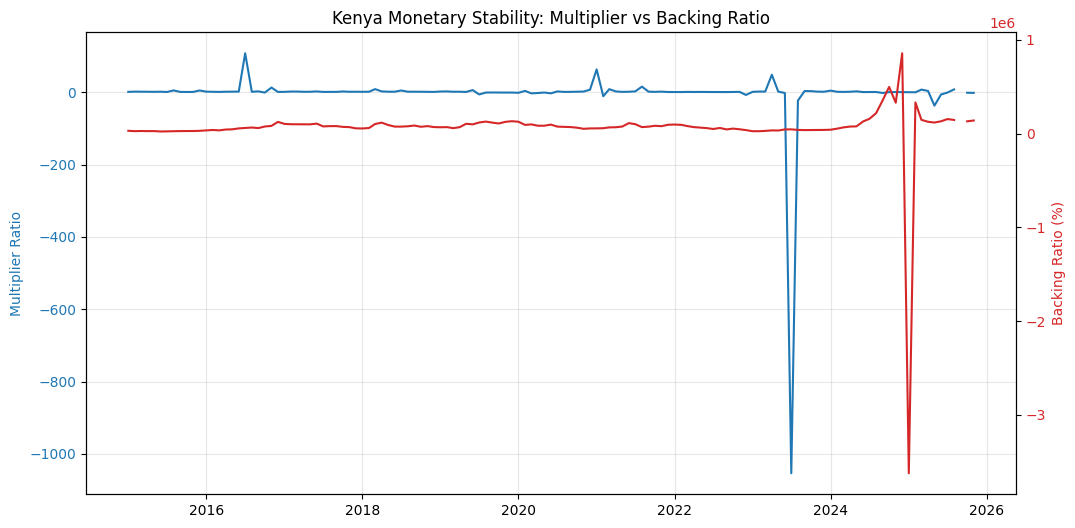

In [ ]:
# 1. Calculating Ratios
df_monetary['Money_Multiplier'] = df_monetary['M3'] / df_monetary['Reserve_Money']
df_monetary['Backing_Ratio'] = df_monetary['NFA'] / df_monetary['M3']

# 2. Visualize
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Multiplier
ax1.plot(df_monetary.index, df_monetary['Money_Multiplier'], color='tab:blue', label='Money Multiplier (M3/RM)')
ax1.set_ylabel('Multiplier Ratio', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plotting Backing Ratio on secondary axis
ax2 = ax1.twinx()
ax2.plot(df_monetary.index, df_monetary['Backing_Ratio'], color='tab:red', label='Backing Ratio (NFA/M3)')
ax2.set_ylabel('Backing Ratio (%)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Kenya Monetary Stability: Multiplier vs Backing Ratio')
ax1.grid(True, alpha=0.3)
plt.show()

## 9. The "Lazy Money" Analysis (Excess Liquidity)-Liquidity Buffer Ratio
When banks hold significant excess reserves, it often means they are either being extremely cautious about lending or that the interest rates they earn elsewhere (like on Government Tontines or T-Bills) aren't attractive enough to move the cash.

In [ ]:
# We calculate the Liquidity Buffer Ratio
df_monetary['Liquidity_Buffer_Ratio'] = (df_monetary['Excess_Reserves'] / 
                                     (df_monetary['Req_Reserves'] + df_monetary['Excess_Reserves'])) * 100

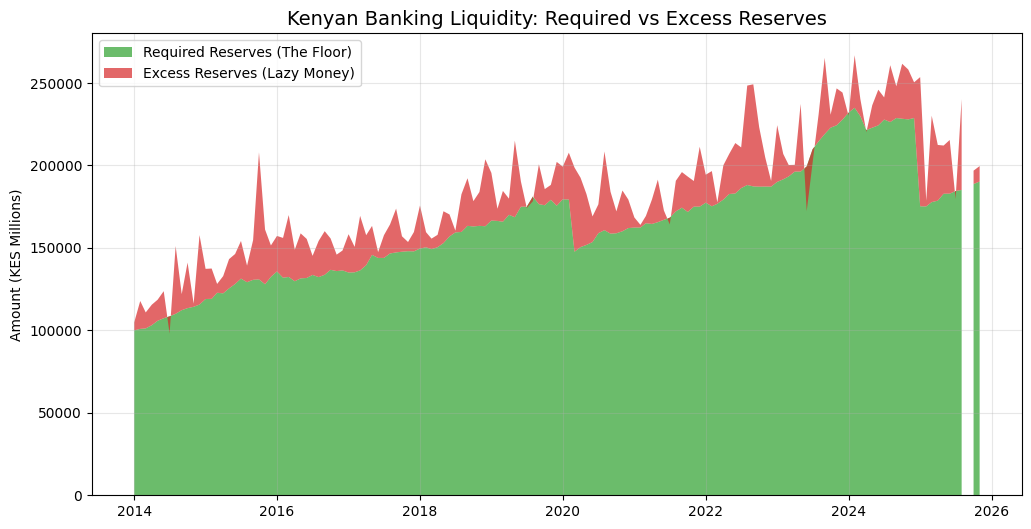

In [ ]:
# Visualization: The Reserve Stack
plt.figure(figsize=(12, 6))
plt.stackplot(df_monetary.index, 
              df_monetary['Req_Reserves'], 
              df_monetary['Excess_Reserves'], 
              labels=['Required Reserves (The Floor)', 'Excess Reserves (Lazy Money)'],
              colors=['#2ca02c', '#d62728'], alpha=0.7)

plt.title('Kenyan Banking Liquidity: Required vs Excess Reserves', fontsize=14)
plt.ylabel('Amount (KES Millions)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

## The "Lazy Money" Index: % of Reserves Not Being Lent

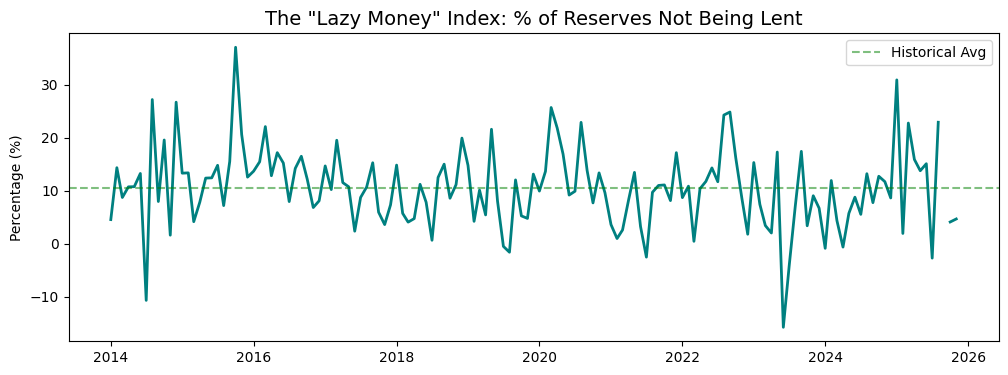

In [ ]:
# Visualization: The "Lazy Money" Index
plt.figure(figsize=(12, 4))
plt.plot(df_monetary.index, df_monetary['Liquidity_Buffer_Ratio'], color='teal', linewidth=2)
plt.axhline(df_monetary['Liquidity_Buffer_Ratio'].mean(), color='green', linestyle='--', alpha=0.5, label='Historical Avg')
plt.title('The "Lazy Money" Index: % of Reserves Not Being Lent', fontsize=14)
plt.ylabel('Percentage (%)')
plt.legend()
plt.show()

## 10. The 'Crowding Out' Index (Government vs. Private Credit)
Calculated as the difference between Government Credit growth and Private Credit growth.

The Index Calculation:$$\text{Crowding Out Index} = \Delta \% \text{Government Credit}_{YoY} - \Delta \% \text{Private Credit}_{YoY}$$

A Positive Signal (Red area rising): Means the government is borrowing faster than the private sector. In macroeconomics, this often leads to higher interest rates for businesses because the government is "consuming" the available loanable funds.

The Trend: If you see the government line consistently above the private line, it suggests that commercial banks find it safer or more profitable to lend to the State (via T-Bills) than to SMEs or households.

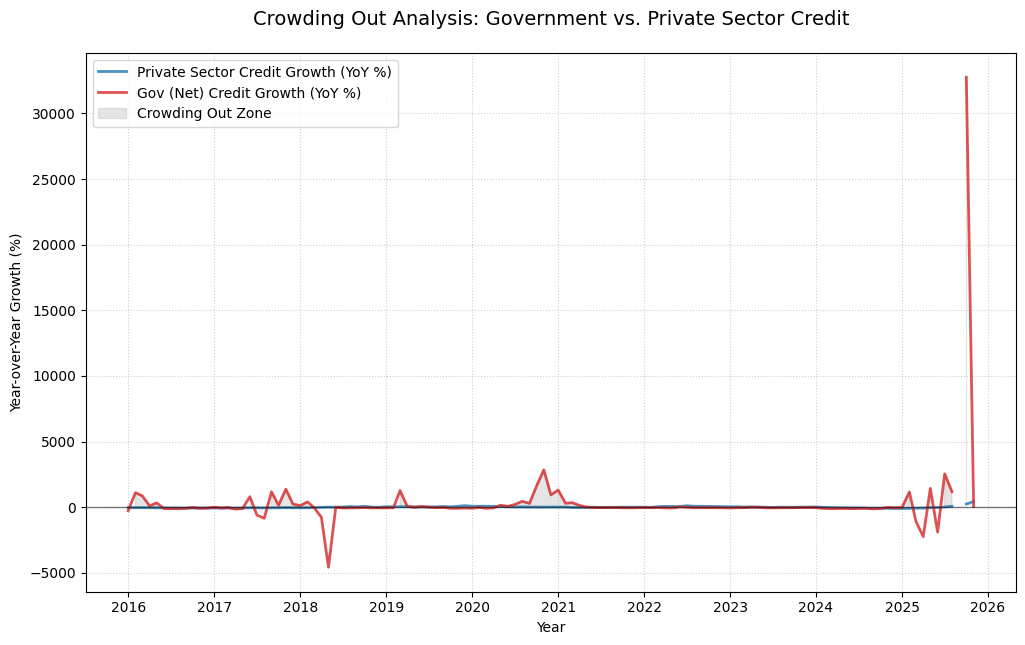

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calculate the YoY Growth Rates (if not already done)
# Assuming 'monetary' is your cleaned DataFrame
df_yoy = df_monetary[['Private_Credit', 'Gov_Credit']].pct_change(periods=12) * 100

# 2. Calculate the Crowding Out Index
# Positive values = Gov borrowing faster than Private sector
# Negative values = Private sector is leading credit absorption
df_yoy['Crowding_Out_Signal'] = df_yoy['Gov_Credit'] - df_yoy['Private_Credit']

# 3. Visualize
plt.figure(figsize=(12, 7))

# Plot the two growth lines
plt.plot(df_yoy.index, df_yoy['Private_Credit'], label='Private Sector Credit Growth (YoY %)', 
         color='#1f77b4', linewidth=2, alpha=0.8)
plt.plot(df_yoy.index, df_yoy['Gov_Credit'], label='Gov (Net) Credit Growth (YoY %)', 
         color='#d62728', linewidth=2, alpha=0.8)

# Fill the "Crowding Out" area
# When Gov > Private, we fill with a warning color (red/gray)
plt.fill_between(df_yoy.index, df_yoy['Gov_Credit'], df_yoy['Private_Credit'], 
                 where=(df_yoy['Gov_Credit'] > df_yoy['Private_Credit']),
                 color='gray', alpha=0.2, label='Crowding Out Zone')

# Aesthetics
plt.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
plt.title('Crowding Out Analysis: Government vs. Private Sector Credit', fontsize=14, pad=20)
plt.ylabel('Year-over-Year Growth (%)')
plt.xlabel('Year')
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)


Let me also focus on the Drivers of Liquidity and Public Sector Dynamics. These analyses help us understand if Kenya's money supply is being fueled by "Hard Assets" (Foreign Exchange) or "Domestic Debt," and whether State-Owned Enterprises (SOEs) are taking a larger slice of the credit pie.

## 11. Sources of Money Supply Growth (NFA vs. NDA)
In monetary economics, Broad Money ($M3$) is created from two sources: Net Foreign Assets (NFA) and Net Domestic Assets (NDA).NFA Driven: Liquidity comes from exports, tourism, or FDI (Stronger KES signal).NDA Driven: Liquidity comes from domestic bank lending and government deficits (Inflationary signal).

In [ ]:
# We calculate the share of each to see what 'backs' the Shilling
df_monetary['NFA_Contribution'] = (df_monetary['NFA'] / df_monetary['M3']) * 100
df_monetary['NDA_Contribution'] = (df_monetary['NDA'] / df_monetary['M3']) * 100

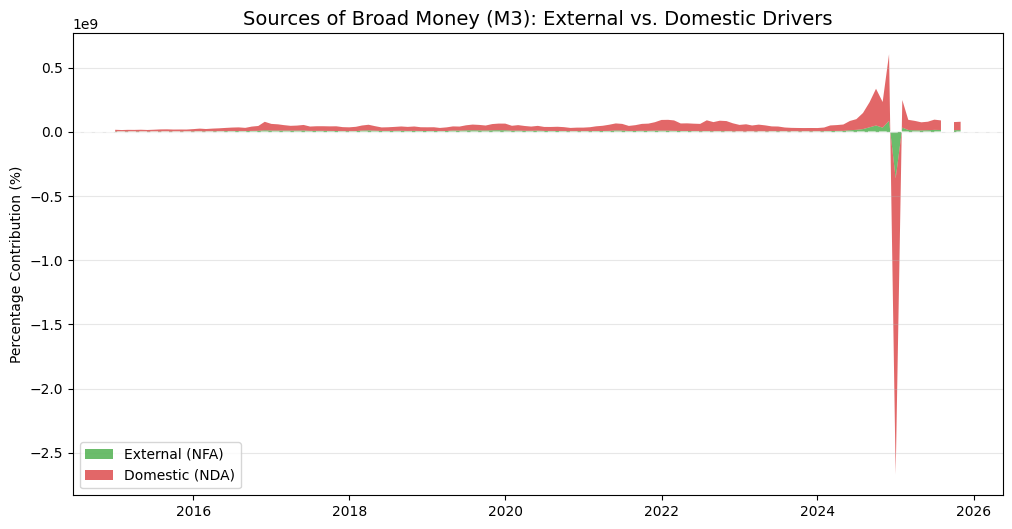

In [ ]:
# NFA vs NDA (The Quality of Money Supply)
plt.figure(figsize=(12, 6))
plt.stackplot(df_monetary.index, df_monetary['NFA_Contribution'], df_monetary['NDA_Contribution'], 
              labels=['External (NFA)', 'Domestic (NDA)'], colors=['#2ca02c', '#d62728'], alpha=0.7)
plt.axhline(50, color='white', linestyle='--', alpha=0.5)
plt.title('Sources of Broad Money (M3): External vs. Domestic Drivers', fontsize=14)
plt.ylabel('Percentage Contribution (%)')
plt.legend(loc='lower left')
plt.grid(axis='y', alpha=0.3)

## 12. SOE vs. Private Sector Credit Tension
While we looked at "Government vs. Private," this analysis looks specifically at Public Non-Financial Corporations (SOEs). If SOE credit grows while Private Sector credit stagnates, it signals a specific type of institutional crowding out.

In [ ]:
# Comparing the growth rates of credit to State Corporations vs Businesses
df_credit_yoy = df_monetary[['SOE_Credit', 'Private_Credit']].pct_change(periods=12) * 100

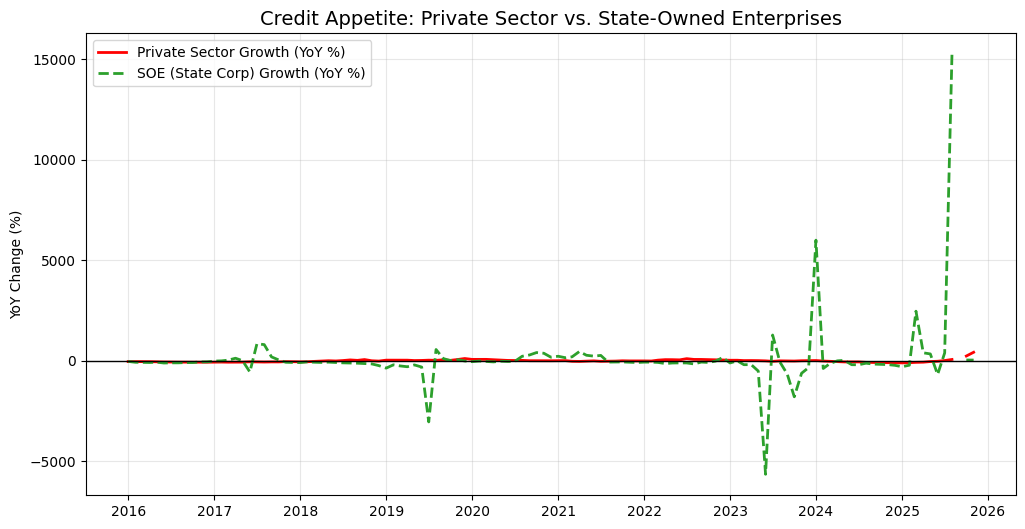

In [ ]:
# SOE vs Private Sector Credit Growth
plt.figure(figsize=(12, 6))
plt.plot(df_credit_yoy.index, df_credit_yoy['Private_Credit'], label='Private Sector Growth (YoY %)', color='red', linewidth=2)
plt.plot(df_credit_yoy.index, df_credit_yoy['SOE_Credit'], label='SOE (State Corp) Growth (YoY %)', color='#2ca02c', linestyle='--', linewidth=2)
plt.axhline(0, color='black', linewidth=1)
plt.title('Credit Appetite: Private Sector vs. State-Owned Enterprises', fontsize=14)
plt.ylabel('YoY Change (%)')
plt.legend()
plt.grid(True, alpha=0.3)

## What these results reveal:
### The NFA/NDA Stack: 
If the Red (NDA) section is expanding while the Green (NFA) section shrinks, the money supply is becoming increasingly "domesticated." This often happens when a country is using its foreign reserves to defend the currency while printing/borrowing domestically to fund the budget.
### SOE Dynamics:
Often, SOE Credit can spike due to large infrastructure projects (SGR, Power plants). However, if SOE credit grows at $20\%+$ while Private Sector growth is at $5\%$, it indicates that the financial system is leaning toward "State Capitalism" rather than "Market-led Growth."